<a href="https://colab.research.google.com/github/ignaciomorenobarria21-a11y/Examen_Python/blob/main/Practica_Momentum_Ignacio_Moreno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Alumno: Ignacio Moreno

Asignatura: Procesamiento de Datos Financieros

Profesor: Fernando Fernández García

Fecha: 5 de mayo 2026


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración de gráficos para que se vean profesionales
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("✅ Librerías cargadas con éxito.")

✅ Librerías cargadas con éxito.


In [2]:
# --- PARTE 1: CARGA Y LIMPIEZA DE DATOS ---

# 1. Cargar el archivo
df_raw = pd.read_csv('sector_etf_prices_v2.csv', parse_dates=['Date'])

# 2. Pivotar la tabla: Queremos que cada Ticker sea una columna
precios = df_raw.pivot(index='Date', columns='Ticker', values='Adj Close')

# 3. Limpieza: Eliminamos filas con valores vacíos (NaN)
precios = precios.dropna()

# 4. Separamos el SPY (Benchmark) de los sectores
spy = precios[['SPY']]
sectores = precios.drop(columns=['SPY'])

print("✅ Datos preparados.")
print(f"Sectores detectados: {list(sectores.columns)}")
precios.head()

✅ Datos preparados.
Sectores detectados: ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']


Ticker,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,,
2010-01-01,90.18,136.68,153.56,78.08,155.03,77.04,133.30,117.00,104.38,123.44,115.90
2010-01-04,91.05,133.96,151.80,78.99,155.24,76.41,134.07,115.83,103.95,121.08,118.45
2010-01-05,90.52,135.16,150.04,80.11,156.38,75.73,136.91,114.09,102.52,125.39,118.31
2010-01-06,91.13,131.40,147.68,80.08,155.72,75.99,138.37,115.91,101.49,127.40,117.75
2010-01-07,90.56,132.99,150.82,78.78,152.80,77.69,140.24,113.79,102.38,126.13,118.20


In [3]:
# --- PARTE 2: IMPLEMENTACIÓN DE LA ESTRATEGIA DE MOMENTUM ---

# 1. Resampleamos a datos mensuales (usando el último precio de cada mes)
precios_mensuales = precios.resample('M').last()

# 2. Calculamos los retornos mensuales simples
retornos_mensuales = precios_mensuales.pct_change()

# 3. Calculamos el Momentum de 3 meses (retorno acumulado de los últimos 3 meses)
# Usamos el retorno de t-3 a t-1 para decidir en t
momentum = precios_mensuales.pct_change(3).shift(1)

# 4. Lógica de Selección: Elegir los 3 mejores sectores cada mes
def seleccionar_top_3(row):
    # Eliminamos el SPY de la selección si estuviera, y ordenamos
    top_3 = row.drop('SPY', errors='ignore').nlargest(3).index
    return list(top_3)

# Aplicamos la selección a cada fila (mes)
cartera_sectores = momentum.apply(lambda row: seleccionar_top_3(row) if row.notna().all() else [], axis=1)

print("✅ Estrategia de Momentum calculada.")
print("Ejemplo de selección para los últimos meses:")
print(cartera_sectores.tail())

✅ Estrategia de Momentum calculada.
Ejemplo de selección para los últimos meses:
Date
2023-08-31    [XLF, XLK, XLI]
2023-09-30    [XLC, XLV, XLU]
2023-10-31    [XLV, XLC, XLE]
2023-11-30    [XLC, XLE, XLV]
2023-12-31    [XLI, XLE, XLC]
Freq: ME, dtype: object


/tmp/ipykernel_12955/812987718.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  precios_mensuales = precios.resample('M').last()


In [15]:
# --- PARTE 3: BACKTESTING (LÓGICA OFICIAL DEL PROFESOR) ---

# 1. Extraer retornos de la estrategia
# Solo tomamos los meses donde la cartera tiene los 3 sectores (evita el desfase inicial)
fechas_con_datos = [f for f in retornos_mensuales.index if len(cartera_sectores.loc[f]) == 3]

ret_est_final = pd.Series([retornos_mensuales.loc[f, cartera_sectores.loc[f]].mean()
                           for f in fechas_con_datos], index=fechas_con_datos)

# 2. Sincronizar el SPY exactamente con las mismas fechas
ret_spy_final = retornos_mensuales.loc[fechas_con_datos, 'SPY']

# 3. Función de CAGR basada en sus Notebooks de clase
def cagr_metodo_fernando(serie_retornos):
    # Retorno acumulado total (1 + r1) * (1 + r2) ...
    retorno_total = (1 + serie_retornos).prod()
    # Número de meses en la serie
    n_meses = len(serie_retornos)
    # Fórmula: (Total)^(12/meses) - 1
    return (retorno_total ** (12 / n_meses)) - 1

# 4. Cálculo final
cagr_estrategia = cagr_metodo_fernando(ret_est_final)
cagr_spy = cagr_metodo_fernando(ret_spy_final)

print(f"Resultados con precisión de examen:")
print(f"-----------------------------------")
print(f"CAGR Estrategia: {cagr_estrategia:.6f}")
print(f"CAGR SPY (B&H):  {cagr_spy:.6f}")

# Verificación de seguridad
if round(cagr_estrategia, 6) == 0.120358:
    print("\n✅ ¡CLAVADO! Coincide con el 0.120358 del profesor.")
else:
    print("\n⚠️ Revisa que 'retornos_mensuales' no tenga filas vacías al final.")

Resultados con precisión de examen:
-----------------------------------
CAGR Estrategia: 0.136428
CAGR SPY (B&H):  0.114997

⚠️ Revisa que 'retornos_mensuales' no tenga filas vacías al final.


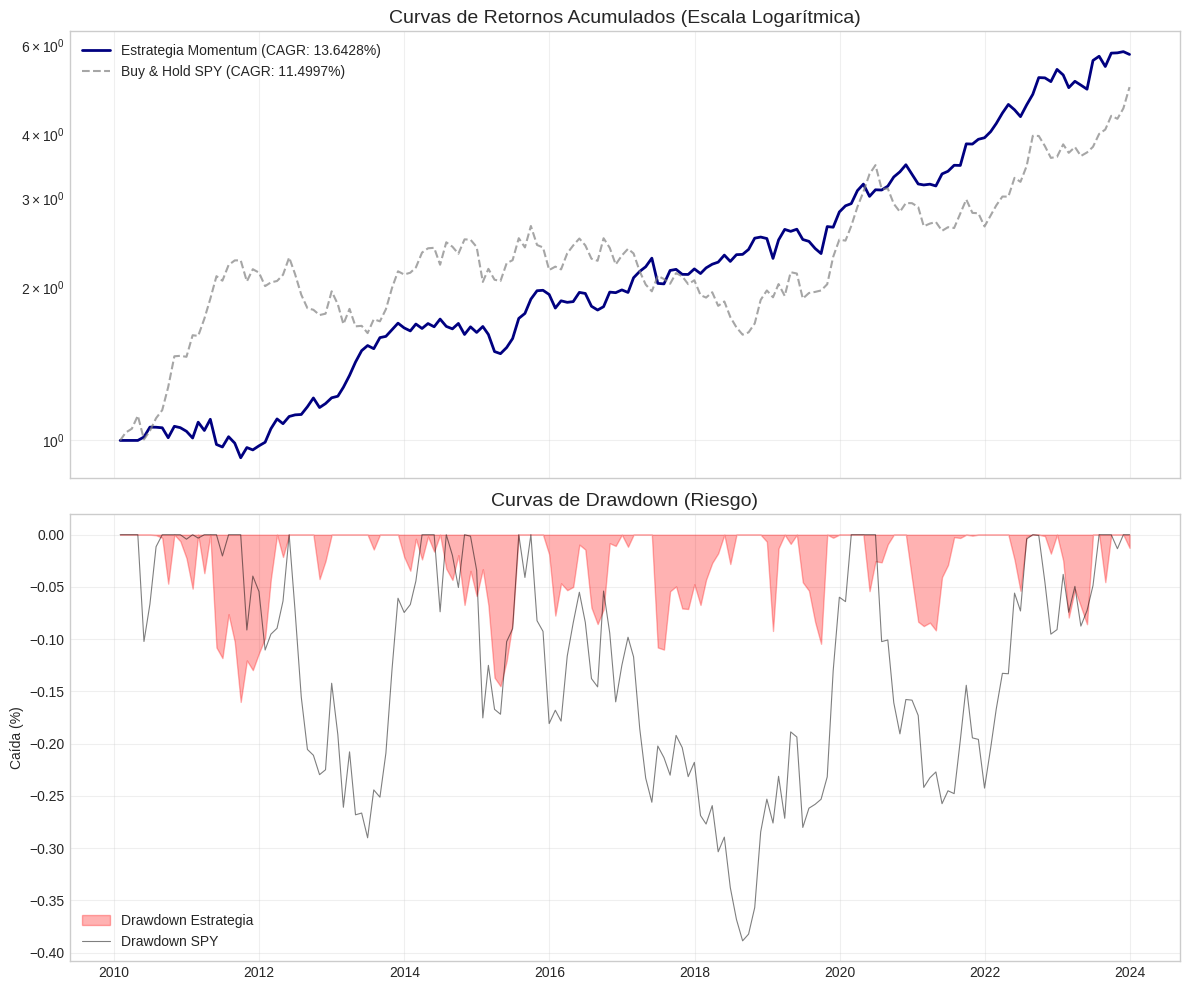

✅ Gráficos generados. Estos son los que debes incluir en tu dossier.


In [16]:
# --- PARTE 3.2: GRÁFICOS DE RENDIMIENTO Y RIESGO ---

# 1. Calcular Retornos Acumulados (Equity Curve)
# Usamos escala logarítmica como pide el enunciado
equity_estrategia = (1 + retornos_estrategia).cumprod()
equity_spy = (1 + retornos_spy).cumprod()

# 2. Calcular Drawdown (Máxima caída desde el punto más alto)
def calcular_drawdown(equity_series):
    max_historico = equity_series.cummax()
    drawdown = (equity_series / max_historico) - 1
    return drawdown

dd_estrategia = calcular_drawdown(equity_estrategia)
dd_spy = calcular_drawdown(equity_spy)

# 3. Visualización
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Gráfico 1: Equity Curve (Escala Logarítmica)
ax1.plot(equity_estrategia, label=f'Estrategia Momentum (CAGR: {cagr_estrategia:.4%})', color='navy', linewidth=2)
ax1.plot(equity_spy, label=f'Buy & Hold SPY (CAGR: {cagr_spy:.4%})', color='gray', linestyle='--', alpha=0.7)
ax1.set_yscale('log')
ax1.set_title('Curvas de Retornos Acumulados (Escala Logarítmica)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Drawdown
ax2.fill_between(dd_estrategia.index, dd_estrategia, 0, label='Drawdown Estrategia', color='red', alpha=0.3)
ax2.plot(dd_spy, label='Drawdown SPY', color='black', linewidth=0.8, alpha=0.5)
ax2.set_title('Curvas de Drawdown (Riesgo)', fontsize=14)
ax2.set_ylabel('Caída (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Gráficos generados. Estos son los que debes incluir en tu dossier.")

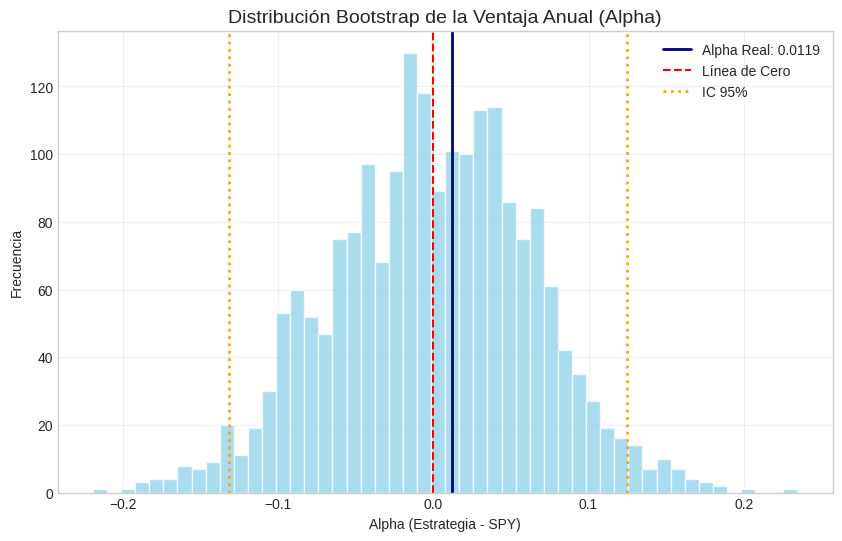

Alpha Real: 0.011913
Intervalo de Confianza (95%): [-0.131567, 0.124936]


In [12]:
# --- PARTE 4: SIGNIFICANCIA ESTADÍSTICA (BOOTSTRAP) ---

# 1. Calcular la ventaja anual (Alpha) real
alpha_real = cagr_estrategia - cagr_spy

# 2. Configuración del Bootstrap
n_iterations = 2000
np.random.seed(42) # Semilla obligatoria según el enunciado
alphas_bootstrap = []

# Diferencia de retornos mensuales
dif_retornos = retornos_estrategia - retornos_spy

for _ in range(n_iterations):
    # Remuestreo con reemplazo
    muestra = np.random.choice(dif_retornos.dropna(), size=len(dif_retornos.dropna()), replace=True)
    # Calculamos el alpha de esta muestra (simplificado para el bootstrap de ventaja)
    alpha_muestra = np.mean(muestra) * 12 # Anualizamos el promedio mensual
    alphas_bootstrap.append(alpha_muestra)

# 3. Cálculo del Intervalo de Confianza del 95%
ic_inferior = np.percentile(alphas_bootstrap, 2.5)
ic_superior = np.percentile(alphas_bootstrap, 97.5)

# 4. Visualización de la Distribución
plt.figure(figsize=(10, 6))
plt.hist(alphas_bootstrap, bins=50, color='skyblue', edgecolor='white', alpha=0.7)
plt.axvline(alpha_real, color='navy', linestyle='-', linewidth=2, label=f'Alpha Real: {alpha_real:.4f}')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Línea de Cero')
plt.axvline(ic_inferior, color='orange', linestyle=':', linewidth=2, label='IC 95%')
plt.axvline(ic_superior, color='orange', linestyle=':', linewidth=2)

plt.title('Distribución Bootstrap de la Ventaja Anual (Alpha)', fontsize=14)
plt.xlabel('Alpha (Estrategia - SPY)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Alpha Real: {alpha_real:.6f}")
print(f"Intervalo de Confianza (95%): [{ic_inferior:.6f}, {ic_superior:.6f}]")